In [3]:
import pandas as pd
import os

train = pd.read_csv("csiro-biomass/train.csv")
test = pd.read_csv("csiro-biomass/test.csv")

train = pd.DataFrame(train)
test = pd.DataFrame(test)
train

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750
...,...,...,...,...,...,...,...,...,...
1780,ID983582017__Dry_Clover_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Clover_g,0.0000
1781,ID983582017__Dry_Dead_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Dead_g,0.0000
1782,ID983582017__Dry_Green_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Green_g,40.9400
1783,ID983582017__Dry_Total_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Total_g,40.9400


### Identified Problem

Now that we have an idea of how our dataset looks like, we now know that our problem is multi-task learning problem, where we're provided an image, and the model must not only classify its target_name correctly, but also its target value. The next step is to see how these two values relate to each other. Below we disply the boxplots of each class in correlation with their values, and we can see that Dry_total_g, Dry_Green_g, and GDM_g have a higher standarad deviation in comparison to Dry_dead_g and Dry_clover_g.

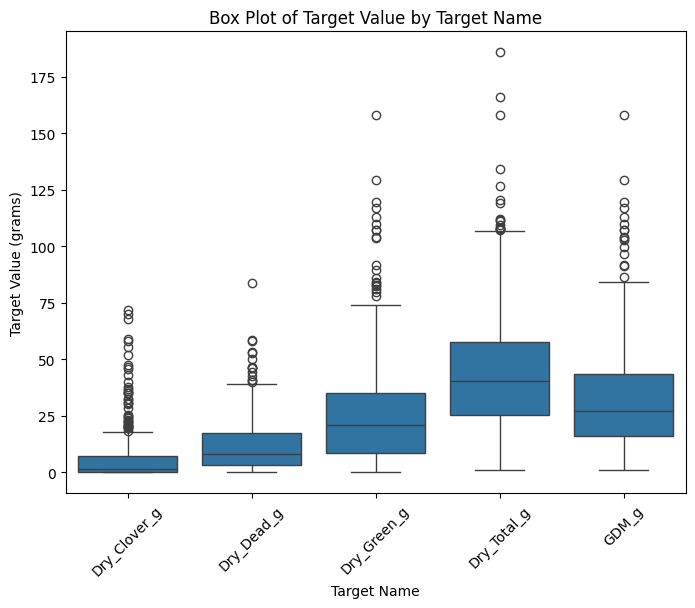

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='target_name', y='target', data=train)
plt.title("Box Plot of Target Value by Target Name")
plt.xlabel("Target Name")
plt.ylabel("Target Value (grams)")
plt.xticks(rotation=45)
plt.show()

Below we are getting a feel for each column that we have, and making sure that we understand our problem before we start building the model.

In [34]:
# Displaying the species
print(train['Species'].unique())
print(f"---------------")
print(train['State'].unique())
print(f"---------------")
train.describe()

['Ryegrass_Clover' 'Lucerne' 'SubcloverDalkeith' 'Ryegrass'
 'Phalaris_Clover' 'SubcloverLosa' 'Clover' 'Fescue_CrumbWeed'
 'Phalaris_Ryegrass_Clover' 'Phalaris' 'WhiteClover' 'Fescue'
 'Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed'
 'Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass' 'Mixed']
---------------
['Tas' 'NSW' 'WA' 'Vic']
---------------


,Pre_GSHH_NDVI,Height_Ave_cm,target
count,1785.000000,1785.000000,1785.000000
mean,0.657423,7.595985,24.782295
std,0.151972,10.273725,25.823738
min,0.160000,1.000000,0.000000
25%,0.560000,3.000000,4.818200
50%,0.690000,4.000000,18.200000
75%,0.770000,7.000000,35.940600
max,0.910000,70.000000,185.700000


In [35]:
print(f"Inputs: {[col for col in train.columns if col not in ['target', 'target_name']]}")
print(f"Outputs: {[col for col in train.columns if col not in ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']]}")

Inputs: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']
Outputs: ['target_name', 'target']


It's clear now that we will need to first convert each image_path into its own image tensor, and feed it into a CNN for processing the image and making raw predictions on it, then fine-tuning our predictions through feeding the CNN outputs into classifications with Sampling_Date, State, Species, and Pre_GSHH_NDVI appended to it. Now we start building the model.